# GP Factor Correlation and Barra/Style Residual Analysis

This notebook starts from `passed_oos_full.csv`, reconstructs GP-mined factor values, measures factor-to-factor correlation, greedily selects a low-correlation subset, and then runs a Barra-style residual analysis using the local crypto style exposure toolkit.

Default scope is the top 40 OOS candidates from 2025-2026 YTD. Increase `MAX_CANDIDATES` after the pipeline works end to end.


In [1]:
import contextlib
import copy
import io
import json
import sys
import traceback
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=RuntimeWarning)

sys.path.insert(0, "/root/crypto-research/common/scripts")
sys.path.insert(0, "/root/crypto-research/common")

from gp.minute_gp_system.engines.unified_v2.evaluate_with_framework import load_gp_entries_batch
from gp.minute_gp_system.engines.unified_v2.data_loader import CryptoDataLoader
from gp.minute_gp_system.engines.unified_v2.config import (
    DEFAULT_FUNDAMENTAL_PANEL_PATH,
    MINUTES_PER_PERIOD,
)
from factor_system.factor_hub.main import FactorManager

from audit_gp_style_residual_gates import (
    CORE_STYLE_FACTORS,
    BROAD_STYLE_FACTORS,
    _build_style_tensor,
    _residualize_batch,
)

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)


In [2]:
# Paths
PASSED_CSV = Path("/home/wesleywu/gp/minute_gp_system/passed_oos_full.csv")
RUNS_ROOT = Path("/home/wesleywu/gp/minute_gp_system/runs_manual")
OUT_DIR = Path("/home/wesleywu/gp/gp_barra/output")
CACHE_DIR = Path("/home/wesleywu/gp/gp_barra/cache_factor_values")

H5_PATH = "/root/crypto-research/common/data/raw/h5/bybit_linear_1m_unified.h5"
FACTOR_BASE_DIR = "/root/crypto-research/common/factor_base"

# Reconstruction keeps warmup history so rolling/decay operators are stable by eval_start.
FACTOR_START_DATE = "20220102"
FACTOR_END_DATE = "20260501"
EVAL_START = "2025-01-01"
EVAL_END = "2026-05-01"

PROFILE_ID = "perp_1d"
COST = 0.0015
PERIODS_PER_YEAR = 365

# Main knobs.
MAX_CANDIDATES = 200
CORR_THRESHOLD = 0.35
HIGH_CORR_THRESHOLD = 0.60
STYLE_SET = "core"  # "core" or "broad"
RIDGE = 1e-4
MIN_OBS = 30

OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

STYLE_NAMES = CORE_STYLE_FACTORS if STYLE_SET == "core" else BROAD_STYLE_FACTORS
print("style factors:", STYLE_NAMES)


style factors: ('cm_log_mcap_lag1', 'dollar_volume_rank', 'amihud_illiq', 'beta_btc_60d', 'corr_btc_20d', 'relative_strength_btc_5d', 'rv_20d', 'rv_ratio_5_20')


In [3]:
def normalize_factor_result_index(factor_result, start, profile_id):
    fr = copy.deepcopy(factor_result)
    sample = None
    for key in ["long_rets", "short_rets", "rankics", "long_turnovers", "short_turnovers"]:
        if key in fr:
            sample = fr[key]
            break
    if sample is None:
        raise ValueError(f"factor_result keys: {list(fr.keys())}")
    if isinstance(sample.index, pd.DatetimeIndex):
        return fr

    freq_map = {"perp_1d": "1D"}
    dt_index = pd.date_range(start=pd.Timestamp(start), periods=len(sample), freq=freq_map.get(profile_id, "1D"))
    series_keys = [
        "long_rets", "long_turnovers", "long_nums",
        "short_rets", "short_turnovers", "short_nums",
        "rankics", "coverages", "universe_nums",
    ]
    for key in series_keys:
        if key in fr and isinstance(fr[key], pd.Series) and len(fr[key]) == len(dt_index):
            fr[key].index = dt_index
    if "group_rets" in fr and isinstance(fr["group_rets"], pd.DataFrame) and len(fr["group_rets"]) == len(dt_index):
        fr["group_rets"].index = dt_index
    return fr


def calc_yearly_ls_metrics(factor_result, start, end, cost, periods_per_year):
    long_rets = factor_result["long_rets"].loc[start:end]
    short_rets = factor_result["short_rets"].loc[start:end]
    long_to = factor_result["long_turnovers"].loc[start:end]
    short_to = factor_result["short_turnovers"].loc[start:end]

    long_netrets = long_rets - long_to / 2 * cost
    short_netrets = short_rets - short_to / 2 * cost
    ls_rets = (long_rets + short_rets) / 2
    ls_netrets = (long_netrets + short_netrets) / 2
    ls_turnover = (long_to + short_to) / 2

    rows = []
    for year, year_netrets in ls_netrets.groupby(ls_netrets.index.year):
        idx = year_netrets.index
        year_rawrets = ls_rets.loc[idx]
        year_turnover = ls_turnover.loc[idx]
        nav = (1 + year_netrets).cumprod()
        dd = nav / nav.cummax() - 1
        sharpe = np.nan
        if len(year_netrets) >= 2 and year_netrets.std() > 1e-12:
            sharpe = float(year_netrets.mean() / year_netrets.std() * np.sqrt(periods_per_year))
        rows.append({
            "period": str(year),
            "ls_netret": float((1 + year_netrets).prod() - 1),
            "ls_netmaxdd": float(-dd.min()) if len(dd) else np.nan,
            "ls_net_sharpe": sharpe,
            "ls_win_rate": float((year_rawrets > 0).mean()) if len(year_rawrets) else np.nan,
            "ls_turnover": float(year_turnover.mean()) if len(year_turnover) else np.nan,
            "n_bars": int(len(year_netrets)),
        })
    if not rows:
        return pd.DataFrame(columns=["period", "ls_netret", "ls_netmaxdd", "ls_net_sharpe", "ls_win_rate", "ls_turnover", "n_bars"]).set_index("period")
    return pd.DataFrame(rows).set_index("period")


def summarize_factor_result(factor_result, start, end, label):
    yearly = calc_yearly_ls_metrics(factor_result, start, end, COST, PERIODS_PER_YEAR).reset_index()
    yearly.insert(0, "label", label)
    return yearly


In [4]:
def load_passed_entries(passed_csv=PASSED_CSV, runs_root=RUNS_ROOT, max_candidates=MAX_CANDIDATES):
    passed = pd.read_csv(passed_csv, encoding="utf-8-sig")
    passed = passed.sort_values(
        ["2026_ls_netret", "2026_ls_net_sharpe", "2025_ls_netret", "2025_ls_net_sharpe"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)
    if max_candidates is not None:
        passed = passed.head(int(max_candidates)).copy()

    pareto_by_run = {}
    for p in sorted(runs_root.glob("gp_2022_2024_seed*/raw/pareto_results.json")):
        with open(p, "r", encoding="utf-8") as f:
            pareto_by_run[p.parts[-3]] = json.load(f)

    entries = []
    misses = []
    for row_i, row in passed.iterrows():
        run_name = str(row["run_name"])
        formula = str(row["formula"])
        rank = int(row["rank"]) if pd.notna(row["rank"]) else None
        candidates = pareto_by_run.get(run_name, [])

        match = None
        for item in candidates:
            if item.get("formula") == formula and item.get("rank") == rank:
                match = dict(item)
                break
        if match is None:
            for item in candidates:
                if item.get("formula") == formula:
                    match = dict(item)
                    break
        if match is None:
            misses.append({"row": row_i, "run_name": run_name, "rank": rank, "formula": formula})
            continue

        match["_row_id"] = f"gp_{row_i:03d}"
        match["_label"] = f"{row_i:03d}_{run_name}_r{rank}"
        match["_run_name"] = run_name
        match["_seed"] = run_name.replace("gp_2022_2024_seed", "")
        for col in passed.columns:
            match[f"_passed_{col}"] = row[col]
        entries.append(match)

    print(f"passed rows used: {len(passed)}")
    print(f"matched reconstructable entries: {len(entries)}")
    print(f"missing pareto matches: {len(misses)}")
    if misses:
        display(pd.DataFrame(misses).head(20))
    return passed, entries


passed_df, entries = load_passed_entries()
passed_df.tail()


passed rows used: 113
matched reconstructable entries: 113
missing pareto matches: 0


,run_name,rank,formula,2025_ls_netret,2025_ls_netmaxdd,2025_ls_net_sharpe,2025_ls_win_rate,2025_ls_turnover,2026_ls_netret,2026_ls_netmaxdd,2026_ls_net_sharpe,2026_ls_win_rate,2026_ls_turnover
108,gp_2022_2024_seed144,3,"ts_decay(cs_zscore(diff_mean(A=open_interest, B=dollar_volume_rank, w=120, sl=0.3, mask=turnover:high_0.6, lag=0)), w=10)",0.233028,0.098264,1.252522,0.556164,0.091387,0.047228,0.066023,1.007886,0.553719,0.228254
109,gp_2022_2024_seed128,3,"ts_decay(ratio_std(A=return_abs, B=turnover, w=120, sl=0.5, mask=open:none, lag=2), w=5)",0.555609,0.043931,3.564864,0.580822,0.326601,0.044953,0.061142,0.989720,0.545455,0.407807
110,gp_2022_2024_seed108,1,"-(ts_decay(cs_zscore(mean(A=spread, w=180, sl=0.3, mask=price_range_pct:low_0.5)), w=5))",0.116166,0.129905,0.873863,0.512329,0.196587,0.020187,0.066543,0.491184,0.520661,0.373064
111,gp_2022_2024_seed109,1,"ts_decay(ratio_std(A=return_abs, B=money_flow, w=120, sl=0.5, mask=turnover:high_0.8, lag=0), w=20)",0.490444,0.047355,3.297422,0.536986,0.251081,0.018948,0.063425,0.469398,0.520661,0.334597
112,gp_2022_2024_seed103,4,"ts_decay(cov(A=premium_close, B=money_flow, w=240, sl=0.3, mask=open:none, lag=2), w=20)",0.213337,0.125104,1.631224,0.545205,0.437442,0.017028,0.055813,0.502668,0.570248,0.448796


## Add manual GP runs

Append newly mined GP runs that are not yet present in `passed_oos_full.csv`, so they participate in the same reconstruction, factor correlation, low-correlation selection, and optional Barra residual analysis flow.


In [5]:
MANUAL_RUN_SPECS = [
    {"run_name": "gp_2023_2025_seed210", "ranks": None},
    {"run_name": "gp_2023_2025_seed211", "ranks": None},
    {"run_name": "gp_2023_2025_seed212", "ranks": None},
]


def load_manual_run_entries(run_name, ranks=None, runs_root=RUNS_ROOT):
    run_dir = runs_root / run_name / "raw"
    pareto_path = run_dir / "pareto_results.json"
    diag_path = run_dir / "candidate_diagnostics.json"

    if not pareto_path.exists():
        raise FileNotFoundError(f"missing pareto results: {pareto_path}")

    with open(pareto_path, "r", encoding="utf-8") as f:
        pareto = json.load(f)

    diag_by_formula = {}
    if diag_path.exists():
        with open(diag_path, "r", encoding="utf-8") as f:
            diag = json.load(f)
        for item in diag.get("candidates", []):
            formula = item.get("formula")
            if formula is not None:
                diag_by_formula[formula] = item.get("metrics", {}) or {}

    rank_filter = None if ranks is None else {int(x) for x in ranks}
    out = []
    for item in pareto:
        rank = int(item["rank"])
        if rank_filter is not None and rank not in rank_filter:
            continue

        entry = dict(item)
        formula = entry.get("formula")
        metrics = diag_by_formula.get(formula, {})
        label = f"manual_{run_name}_r{rank}"

        entry["_row_id"] = label
        entry["_label"] = label
        entry["_run_name"] = run_name
        entry["_seed"] = run_name.split("seed")[-1]

        # Greedy selection expects passed_oos_full-style columns. For manual runs,
        # use candidate diagnostics as ordering proxies until split-year OOS rows exist.
        entry["_passed_2026_ls_netret"] = metrics.get("ls_netret", np.nan)
        entry["_passed_2026_ls_net_sharpe"] = metrics.get("ls_net_sharpe", np.nan)
        entry["_passed_2025_ls_netret"] = metrics.get("min_yearly_ls_netret", np.nan)
        entry["_passed_2025_ls_net_sharpe"] = metrics.get("min_yearly_ls_net_sharpe", np.nan)
        entry["_passed_2026_ls_turnover"] = metrics.get("turnover", np.nan)
        out.append(entry)

    return out


manual_entries = []
for spec in MANUAL_RUN_SPECS:
    manual_entries.extend(load_manual_run_entries(**spec))

manual_run_names = {spec["run_name"] for spec in MANUAL_RUN_SPECS}
entries = [e for e in entries if e.get("_run_name") not in manual_run_names]
entries = entries + manual_entries
manual_labels = [e["_label"] for e in manual_entries]

print("manual entries added:", len(manual_entries))
print(manual_labels)


manual entries added: 4
['manual_gp_2023_2025_seed210_r1', 'manual_gp_2023_2025_seed210_r2', 'manual_gp_2023_2025_seed211_r1', 'manual_gp_2023_2025_seed212_r1']


In [6]:
from pathlib import Path
import contextlib
import io
import traceback
import pandas as pd

CACHE_DIR = Path("/home/wesleywu/gp/gp_barra/cache_factor_values")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def stable_cache_label(entry):
    """
    Stable cache key independent of current dataframe row order.

    Old labels look like:
        004_gp_2022_2024_seed139_r20

    Stable labels become:
        gp_2022_2024_seed139_r20
    """
    label = entry["_label"]

    parts = label.split("_", 1)
    if len(parts) == 2 and parts[0].isdigit() and len(parts[0]) == 3:
        return parts[1]

    return label


def _cache_path(entry):
    return CACHE_DIR / f"{stable_cache_label(entry)}.parquet"


def _legacy_cache_path(entry):
    """
    Find old cache files whose names contain row-number prefixes.

    Example:
        current stable label: gp_2022_2024_seed139_r20
        legacy file:          004_gp_2022_2024_seed139_r20.parquet
    """
    stable = stable_cache_label(entry)
    matches = sorted(CACHE_DIR.glob(f"???_{stable}.parquet"))

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1:
        raise RuntimeError(f"multiple legacy cache matches for {stable}: {matches}")

    return None


def _read_cached_factor(entry):
    """
    Prefer stable cache path. Fall back to legacy numbered cache path.
    If legacy cache is found, copy it forward into the stable cache name.
    """
    path = _cache_path(entry)

    if path.exists():
        return pd.read_parquet(path), path

    legacy_path = _legacy_cache_path(entry)
    if legacy_path is not None and legacy_path.exists():
        factor_df = pd.read_parquet(legacy_path)

        # Migrate to stable cache name so future runs hit directly.
        factor_df.to_parquet(path)

        return factor_df, legacy_path

    return None, None


def reconstruct_factor_values(entries, batch_size=4, force=False):
    factors = {}
    used_entries = {}
    pending = []

    cache_hits = 0
    legacy_hits = 0

    for entry in entries:
        label = entry["_label"]

        if not force:
            factor_df, hit_path = _read_cached_factor(entry)

            if factor_df is not None:
                factors[label] = factor_df
                used_entries[label] = entry
                cache_hits += 1

                if hit_path.name != _cache_path(entry).name:
                    legacy_hits += 1

                continue

        pending.append(entry)

    print(f"loaded from cache: {cache_hits}")
    print(f"loaded from legacy cache and migrated: {legacy_hits}")
    print(f"pending reconstruction: {len(pending)}")

    for start in range(0, len(pending), batch_size):
        batch = pending[start:start + batch_size]
        labels = [x["_label"] for x in batch]

        print(
            f"reconstructing {start + 1}-{start + len(batch)} / {len(pending)}",
            labels,
        )

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                frames = load_gp_entries_batch(
                    batch,
                    h5_path=H5_PATH,
                    start_date=FACTOR_START_DATE,
                    end_date=FACTOR_END_DATE,
                    minutes_per_period=MINUTES_PER_PERIOD,
                    backend="cpu",
                    reconstruction_batch_size=len(batch),
                    chunk_periods=5,
                    direction_policy="formula",
                )

            for factor_df, used_entry in frames:
                label = used_entry["_label"]

                factor_df.to_parquet(_cache_path(used_entry))

                factors[label] = factor_df
                used_entries[label] = used_entry

        except Exception as exc:
            print("FAILED batch:", labels, repr(exc))
            traceback.print_exc(limit=1)

    print(f"available factors: {len(factors)}")
    return factors, used_entries


factor_values, used_entries = reconstruct_factor_values(
    entries,
    batch_size=4,
    force=False,
)

list(factor_values)[:5]

loaded from cache: 116
loaded from legacy cache and migrated: 0
pending reconstruction: 1
reconstructing 1-1 / 1 ['manual_gp_2023_2025_seed212_r1']
available factors: 117


['000_gp_2022_2024_seed140_r9',
 '001_gp_2022_2024_seed116_r1',
 '002_gp_2022_2024_seed116_r4',
 '003_gp_2022_2024_seed120_r1',
 '004_gp_2022_2024_seed140_r7']

In [7]:
def date_key_index(index):
    idx = pd.Index(index)
    if np.issubdtype(idx.dtype, np.datetime64):
        return pd.Index(pd.to_datetime(idx).strftime("%Y%m%d"))
    raw = idx.map(str).str.replace("-", "", regex=False).str.slice(0, 8)
    return pd.Index(raw)


def row_zscore_df(df, min_count=20):
    x = df.astype(float).copy()
    mu = x.mean(axis=1, skipna=True)
    sd = x.std(axis=1, skipna=True).replace(0.0, np.nan)
    z = x.sub(mu, axis=0).div(sd, axis=0)
    z[x.notna().sum(axis=1) < min_count] = np.nan
    return z


def align_eval_panel(df, start=EVAL_START, end=EVAL_END):
    out = df.copy()
    out.index = pd.to_datetime(out.index)
    out = out.sort_index().loc[pd.Timestamp(start):pd.Timestamp(end)]
    return out


def mean_daily_corr(a, b, min_obs=30):
    common_dates = a.index.intersection(b.index)
    common_cols = a.columns.intersection(b.columns)
    vals = []
    for dt in common_dates:
        x = a.loc[dt, common_cols]
        y = b.loc[dt, common_cols]
        ok = np.isfinite(x.to_numpy()) & np.isfinite(y.to_numpy())
        if int(ok.sum()) < min_obs:
            continue
        xv = x.to_numpy(dtype=float)[ok]
        yv = y.to_numpy(dtype=float)[ok]
        xs = xv.std()
        ys = yv.std()
        if xs <= 1e-12 or ys <= 1e-12:
            continue
        vals.append(float(np.corrcoef(xv, yv)[0, 1]))
    if not vals:
        return np.nan
    return float(np.nanmean(vals))


def build_corr_matrix(factor_values):
    labels = list(factor_values)
    panels = {k: row_zscore_df(align_eval_panel(v)) for k, v in factor_values.items()}
    corr = pd.DataFrame(np.eye(len(labels)), index=labels, columns=labels, dtype=float)
    for i, li in enumerate(labels):
        for j in range(i + 1, len(labels)):
            lj = labels[j]
            c = mean_daily_corr(panels[li], panels[lj])
            corr.loc[li, lj] = c
            corr.loc[lj, li] = c
    return corr


def high_corr_pairs(corr, threshold=HIGH_CORR_THRESHOLD):
    rows = []
    labels = list(corr.index)
    for i, a in enumerate(labels):
        for b in labels[i + 1:]:
            c = corr.loc[a, b]
            if pd.notna(c) and abs(c) >= threshold:
                rows.append({"factor_a": a, "factor_b": b, "corr": c, "abs_corr": abs(c)})
    if not rows:
        return pd.DataFrame(columns=["factor_a", "factor_b", "corr", "abs_corr"])
    return pd.DataFrame(rows).sort_values("abs_corr", ascending=False).reset_index(drop=True)


def greedy_low_corr_select(corr, entries_by_label, threshold=CORR_THRESHOLD):
    quality = []
    for label, entry in entries_by_label.items():
        quality.append({
            "label": label,
            "2026_ls_netret": float(entry.get("_passed_2026_ls_netret", np.nan)),
            "2026_ls_net_sharpe": float(entry.get("_passed_2026_ls_net_sharpe", np.nan)),
            "2025_ls_netret": float(entry.get("_passed_2025_ls_netret", np.nan)),
        })
    order = pd.DataFrame(quality).sort_values(
        ["2026_ls_netret", "2026_ls_net_sharpe", "2025_ls_netret"],
        ascending=[False, False, False],
    )["label"].tolist()

    selected = []
    decisions = []
    for label in order:
        if not selected:
            selected.append(label)
            decisions.append({"label": label, "selected": True, "max_abs_corr_to_selected": 0.0})
            continue
        max_abs = float(corr.loc[label, selected].abs().max())
        keep = max_abs <= threshold
        if keep:
            selected.append(label)
        decisions.append({"label": label, "selected": keep, "max_abs_corr_to_selected": max_abs})
    return selected, pd.DataFrame(decisions)


corr_matrix = build_corr_matrix(factor_values)
corr_matrix.to_csv(OUT_DIR / "gp_factor_corr_matrix.csv")

high_pairs = high_corr_pairs(corr_matrix)
high_pairs.to_csv(OUT_DIR / "gp_factor_high_corr_pairs.csv", index=False)

selected_labels, selection_log = greedy_low_corr_select(corr_matrix, used_entries)
selection_log.to_csv(OUT_DIR / "gp_factor_low_corr_selection_log.csv", index=False)

print("selected low-corr factors:", len(selected_labels))
display(selection_log.head(30))
display(high_pairs.head(30))
corr_matrix.loc[selected_labels, selected_labels]


selected low-corr factors: 5


,label,selected,max_abs_corr_to_selected
0,manual_gp_2023_2025_seed211_r1,True,0.000000
1,manual_gp_2023_2025_seed212_r1,False,0.597074
2,000_gp_2022_2024_seed140_r9,True,0.163955
3,001_gp_2022_2024_seed116_r1,False,0.563192
4,002_gp_2022_2024_seed116_r4,False,0.781422
5,003_gp_2022_2024_seed120_r1,False,0.544235
6,004_gp_2022_2024_seed140_r7,False,0.560705
7,manual_gp_2023_2025_seed210_r1,False,0.490579
8,005_gp_2022_2024_seed124_r2,False,0.578902
9,006_gp_2022_2024_seed139_r20,False,0.418552


,factor_a,factor_b,corr,abs_corr
0,032_gp_2022_2024_seed140_r2,042_gp_2022_2024_seed142_r2,1.000000,1.000000
1,054_gp_2022_2024_seed142_r1,055_gp_2022_2024_seed143_r1,1.000000,1.000000
2,074_gp_2022_2024_seed108_r2,075_gp_2022_2024_seed131_r3,1.000000,1.000000
3,037_gp_2022_2024_seed101_r2,038_gp_2022_2024_seed114_r1,1.000000,1.000000
4,039_gp_2022_2024_seed111_r1,044_gp_2022_2024_seed125_r4,0.999999,0.999999
5,030_gp_2022_2024_seed140_r3,032_gp_2022_2024_seed140_r2,0.999995,0.999995
6,030_gp_2022_2024_seed140_r3,042_gp_2022_2024_seed142_r2,0.999995,0.999995
7,054_gp_2022_2024_seed142_r1,066_gp_2022_2024_seed146_r3,0.999967,0.999967
8,055_gp_2022_2024_seed143_r1,066_gp_2022_2024_seed146_r3,0.999967,0.999967
9,056_gp_2022_2024_seed103_r1,077_gp_2022_2024_seed120_r3,0.999958,0.999958


,manual_gp_2023_2025_seed211_r1,000_gp_2022_2024_seed140_r9,045_gp_2022_2024_seed139_r14,101_gp_2022_2024_seed139_r18,106_gp_2022_2024_seed125_r3
manual_gp_2023_2025_seed211_r1,1.000000,0.163955,0.284449,0.062054,0.011354
000_gp_2022_2024_seed140_r9,0.163955,1.000000,0.335196,0.193719,0.009014
045_gp_2022_2024_seed139_r14,0.284449,0.335196,1.000000,0.120898,0.056362
101_gp_2022_2024_seed139_r18,0.062054,0.193719,0.120898,1.000000,0.034595
106_gp_2022_2024_seed125_r3,0.011354,0.009014,0.056362,0.034595,1.000000


## Manual run correlation report

Summarize how the newly appended manual factors correlate with the existing GP factor library before deciding whether they deserve Barra residual analysis or final selection.


In [ ]:
manual_labels_in_corr = [label for label in manual_labels if label in corr_matrix.index]
existing_labels_for_manual = [label for label in corr_matrix.index if label not in manual_labels_in_corr]

if manual_labels_in_corr and existing_labels_for_manual:
    manual_corr_to_existing = corr_matrix.loc[manual_labels_in_corr, existing_labels_for_manual]

    new_corr_report = pd.DataFrame({
        "label": manual_labels_in_corr,
        "max_abs_corr_to_existing": manual_corr_to_existing.abs().max(axis=1).values,
        "mean_abs_corr_to_existing": manual_corr_to_existing.abs().mean(axis=1).values,
        "most_corr_existing_label": manual_corr_to_existing.abs().idxmax(axis=1).values,
    })
    new_corr_report["corr_to_most_corr_existing"] = [
        corr_matrix.loc[row.label, row.most_corr_existing_label]
        for row in new_corr_report.itertuples(index=False)
    ]
    new_corr_report = new_corr_report.sort_values(
        "max_abs_corr_to_existing", ascending=False
    ).reset_index(drop=True)
    new_corr_report.to_csv(OUT_DIR / "new_factor_corr_to_existing.csv", index=False)

    manual_high_corr_pairs = high_corr_pairs(
        corr_matrix.loc[manual_labels_in_corr + existing_labels_for_manual, manual_labels_in_corr + existing_labels_for_manual],
        threshold=HIGH_CORR_THRESHOLD,
    )
    manual_high_corr_pairs = manual_high_corr_pairs[
        manual_high_corr_pairs["factor_a"].isin(manual_labels_in_corr)
        | manual_high_corr_pairs["factor_b"].isin(manual_labels_in_corr)
    ].reset_index(drop=True)
    manual_high_corr_pairs.to_csv(OUT_DIR / "new_factor_high_corr_pairs.csv", index=False)

    display(new_corr_report)
    display(manual_high_corr_pairs.head(30))
else:
    print("No manual labels or existing labels available for manual correlation report.")


In [7]:
def normalize_symbol(value):
    if isinstance(value, bytes):
        return value.decode("utf-8")
    return str(value)


def make_style_loader():
    return CryptoDataLoader(
        h5_path=H5_PATH,
        minutes_per_period=MINUTES_PER_PERIOD,
        chunk_periods=120,
        start_date=FACTOR_START_DATE,
        end_date=FACTOR_END_DATE,
        backend="cpu",
    )


def align_factor_to_loader(df, active_dates, symbols):
    frame = df.copy()
    frame.columns = [normalize_symbol(c) for c in frame.columns]
    frame.index = date_key_index(frame.index)
    if frame.index.has_duplicates:
        frame = frame[~frame.index.duplicated(keep="last")]
    aligned = frame.reindex(index=active_dates, columns=symbols)
    return aligned.to_numpy(dtype=np.float32, copy=True)


def residual_array_to_df(arr, active_dates, symbols):
    idx = pd.to_datetime(pd.Index(active_dates), format="%Y%m%d", errors="coerce")
    return pd.DataFrame(arr, index=idx, columns=symbols)


def factor_style_r2_and_beta(factor_arr, styles, tradable, style_names, min_obs=MIN_OBS, ridge=RIDGE):
    rows = []
    k = styles.shape[2]
    for t in range(factor_arr.shape[0]):
        y = factor_arr[t]
        base = tradable[t] & np.isfinite(y)
        if int(base.sum()) < max(min_obs, k + 5):
            continue
        X = np.nan_to_num(styles[t, base, :].astype(np.float64), nan=0.0)
        yv = y[base].astype(np.float64)
        yv = yv - yv.mean()
        ysd = yv.std()
        if ysd <= 1e-12:
            continue
        yz = yv / ysd
        X = X - X.mean(axis=0, keepdims=True)
        xsd = X.std(axis=0, keepdims=True)
        good = (xsd[0] > 1e-12) & np.isfinite(xsd[0])
        if not good.any():
            continue
        Xg = X[:, good] / xsd[:, good]
        Xreg = np.column_stack([np.ones(Xg.shape[0]), Xg])
        reg = np.eye(Xreg.shape[1]) * ridge
        reg[0, 0] = 0.0
        try:
            beta = np.linalg.solve(Xreg.T @ Xreg + reg, Xreg.T @ yz)
        except np.linalg.LinAlgError:
            beta = np.linalg.lstsq(Xreg.T @ Xreg + reg, Xreg.T @ yz, rcond=None)[0]
        pred = Xreg @ beta
        ss_tot = float(np.sum((yz - yz.mean()) ** 2))
        ss_res = float(np.sum((yz - pred) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan
        full_beta = np.full(k, np.nan)
        full_beta[np.flatnonzero(good)] = beta[1:]
        row = {"date": active_dates[t], "r2": r2, "n_obs": int(base.sum())}
        for name, val in zip(style_names, full_beta):
            row[f"beta_{name}"] = val
        rows.append(row)
    return pd.DataFrame(rows)


style_loader = make_style_loader()
active_dates = np.asarray([str(x) for x in style_loader.get_active_dates()])
symbols = [normalize_symbol(style_loader.symbols[i]) for i in style_loader.coin_indices]
tradable = style_loader.get_period_tradable_mask()
styles, style_meta = _build_style_tensor(
    style_loader,
    tuple(STYLE_NAMES),
    fundamental_panel_path=DEFAULT_FUNDAMENTAL_PANEL_PATH,
)
style_meta


{'style_names': ['cm_log_mcap_lag1',
  'dollar_volume_rank',
  'amihud_illiq',
  'beta_btc_60d',
  'corr_btc_20d',
  'relative_strength_btc_5d',
  'rv_20d',
  'rv_ratio_5_20'],
 'style_coverage': {'cm_log_mcap_lag1': 0.8343779163036705,
  'dollar_volume_rank': 0.9987369145189985,
  'amihud_illiq': 0.9984380594721544,
  'beta_btc_60d': 0.9722262163541376,
  'corr_btc_20d': 0.9890072091731583,
  'relative_strength_btc_5d': 0.9960021089016513,
  'rv_20d': 0.9890128479476271,
  'rv_ratio_5_20': 0.9890128479476271},
 'all_style_valid_ratio_on_tradable': 0.8219162247277176}

In [8]:
fm = FactorManager(h5_path=H5_PATH, base_dir=FACTOR_BASE_DIR)


def evaluate_factor_df(label, factor_df):
    result = fm.evaluate(
        factor_df,
        profile_id=PROFILE_ID,
        plot=False,
        params={"start": EVAL_START, "end": EVAL_END, "cost": COST},
    )
    raw = result["factor_result"]["raw"]
    normalized = normalize_factor_result_index(raw, start=pd.Timestamp(EVAL_START), profile_id=PROFILE_ID)
    yearly = summarize_factor_result(normalized, EVAL_START, EVAL_END, label)
    return result, yearly


def run_barra_analysis(labels):
    summary_rows = []
    yearly_rows = []
    residual_values = {}
    beta_detail = {}

    for i, label in enumerate(labels, start=1):
        print(f"[{i}/{len(labels)}] barra residual analysis: {label}")
        original_df = factor_values[label]
        arr = align_factor_to_loader(original_df, active_dates, symbols)
        residual = _residualize_batch(
            arr[None, :, :],
            styles,
            tradable,
            ridge=RIDGE,
            min_obs=MIN_OBS,
        )[0]
        residual_df = residual_array_to_df(residual, active_dates, symbols).loc[pd.Timestamp(EVAL_START):pd.Timestamp(EVAL_END)]
        residual_values[label] = residual_df

        beta_df = factor_style_r2_and_beta(arr, styles, tradable, STYLE_NAMES)
        beta_detail[label] = beta_df

        try:
            _, raw_yearly = evaluate_factor_df(label + "__raw", original_df)
            _, resid_yearly = evaluate_factor_df(label + "__barra_resid", residual_df)
            yearly_rows.append(raw_yearly)
            yearly_rows.append(resid_yearly)

            raw_agg = raw_yearly.set_index("period")
            resid_agg = resid_yearly.set_index("period")
            raw_total = float(np.prod(1 + raw_agg["ls_netret"]) - 1) if len(raw_agg) else np.nan
            resid_total = float(np.prod(1 + resid_agg["ls_netret"]) - 1) if len(resid_agg) else np.nan
            raw_sharpe_mean = float(raw_agg["ls_net_sharpe"].mean()) if len(raw_agg) else np.nan
            resid_sharpe_mean = float(resid_agg["ls_net_sharpe"].mean()) if len(resid_agg) else np.nan
        except Exception as exc:
            print("evaluation failed:", label, repr(exc))
            traceback.print_exc(limit=1)
            raw_total = resid_total = raw_sharpe_mean = resid_sharpe_mean = np.nan

        r2_mean = float(beta_df["r2"].mean()) if len(beta_df) else np.nan
        r2_median = float(beta_df["r2"].median()) if len(beta_df) else np.nan
        row = {
            "label": label,
            "run_name": used_entries[label]["_run_name"],
            "rank": used_entries[label].get("rank"),
            "formula": used_entries[label].get("formula"),
            "raw_total_ls_netret": raw_total,
            "resid_total_ls_netret": resid_total,
            "resid_retention": resid_total / raw_total if raw_total and np.isfinite(raw_total) else np.nan,
            "raw_mean_yearly_sharpe": raw_sharpe_mean,
            "resid_mean_yearly_sharpe": resid_sharpe_mean,
            "style_r2_mean": r2_mean,
            "style_r2_median": r2_median,
        }
        for name in STYLE_NAMES:
            col = f"beta_{name}"
            row[f"mean_beta_{name}"] = float(beta_df[col].mean()) if col in beta_df else np.nan
            row[f"mean_abs_beta_{name}"] = float(beta_df[col].abs().mean()) if col in beta_df else np.nan
        summary_rows.append(row)

    summary = pd.DataFrame(summary_rows).sort_values(
        ["resid_total_ls_netret", "resid_mean_yearly_sharpe", "style_r2_mean"],
        ascending=[False, False, True],
    )
    yearly = pd.concat(yearly_rows, ignore_index=True) if yearly_rows else pd.DataFrame()
    return summary, yearly, residual_values, beta_detail


barra_summary, barra_yearly, residual_values, beta_detail = run_barra_analysis(selected_labels)
barra_summary.to_csv(OUT_DIR / "selected_lowcorr_barra_summary.csv", index=False)
barra_yearly.to_csv(OUT_DIR / "selected_lowcorr_barra_yearly.csv", index=False)

display(barra_summary)
display(barra_yearly.head(50))


[1/5] barra residual analysis: 000_gp_2022_2024_seed140_r9


/root/.pyenv/versions/3.9.0/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:324: NumbaSystemWarning: Could not obtain multiprocessing lock due to OS level error: [Errno 13] Permission denied
A likely cause of this problem is '/dev/shm' is missing or read-only such that necessary semaphores cannot be written.
*** The responsibility of ensuring multiprocessing safe access to this initialization sequence/module import is deferred to the user! ***

  warnings.warn(msg % str(e), errors.NumbaSystemWarning)


calc factor result time:  20.365870734211057 sec
calc factor performance time:  0.005323837045580149 sec
calc factor result time:  0.7941917162388563 sec
calc factor performance time:  0.005441891960799694 sec
[2/5] barra residual analysis: 001_gp_2022_2024_seed116_r1
calc factor result time:  2.0911050401628017 sec
calc factor performance time:  0.005188478156924248 sec
calc factor result time:  0.7964405459351838 sec
calc factor performance time:  0.005460361950099468 sec
[3/5] barra residual analysis: 042_gp_2022_2024_seed139_r14
calc factor result time:  2.0727290897630155 sec
calc factor performance time:  0.00518307788297534 sec
calc factor result time:  0.8046488561667502 sec
calc factor performance time:  0.006074522156268358 sec
[4/5] barra residual analysis: 094_gp_2022_2024_seed139_r18
calc factor result time:  2.0188349611125886 sec
calc factor performance time:  0.0071509419940412045 sec
calc factor result time:  0.7855818779207766 sec
calc factor performance time:  0.0053

,label,run_name,rank,formula,raw_total_ls_netret,resid_total_ls_netret,resid_retention,raw_mean_yearly_sharpe,resid_mean_yearly_sharpe,style_r2_mean,...,mean_beta_beta_btc_60d,mean_abs_beta_beta_btc_60d,mean_beta_corr_btc_20d,mean_abs_beta_corr_btc_20d,mean_beta_relative_strength_btc_5d,mean_abs_beta_relative_strength_btc_5d,mean_beta_rv_20d,mean_abs_beta_rv_20d,mean_beta_rv_ratio_5_20,mean_abs_beta_rv_ratio_5_20
1,001_gp_2022_2024_seed116_r1,gp_2022_2024_seed116,1,"ts_decay(ratio_std(A=price_range_pct, B=turnover, w=120, sl=None, mask=return_abs:high_0.8, lag=1), w=10)",0.720530,0.059981,0.083245,3.311762,-0.307560,0.477369,...,0.005149,0.059387,-0.028274,0.076447,0.023998,0.074779,0.032296,0.075121,-0.050572,0.079022
2,042_gp_2022_2024_seed139_r14,gp_2022_2024_seed139,14,"-(ts_decay(cs_zscore(slope(A=turnover, B=volume_intensity, w=180, sl=0.3, mask=market_vol_intensity:high_0.8, lag=0)), w=20))",0.532705,0.026675,0.050074,2.294356,0.993005,0.487672,...,-0.016292,0.087882,0.028336,0.082058,-0.062520,0.110826,-0.070584,0.123248,-0.101603,0.118871
4,099_gp_2022_2024_seed125_r3,gp_2022_2024_seed125,3,"ts_decay(cov(A=money_flow, B=premium_close, w=240, sl=0.3, mask=open:none, lag=2), w=20)",0.255059,-0.109981,-0.431198,1.451154,-0.899565,0.125794,...,0.025040,0.109223,0.035740,0.113888,-0.083083,0.163434,-0.044160,0.162625,-0.058602,0.115656
0,000_gp_2022_2024_seed140_r9,gp_2022_2024_seed140,9,"-(ts_decay(ratio_mean(A=money_flow, B=rv_20d, w=240, sl=None, mask=open_interest:high_0.8, lag=0), w=20))",0.431487,-0.318886,-0.739040,2.311978,-0.470973,0.526995,...,-0.006151,0.065277,0.029811,0.124458,-0.059474,0.076039,0.076494,0.118553,-0.047422,0.074054
3,094_gp_2022_2024_seed139_r18,gp_2022_2024_seed139,18,"-(ts_decay(cs_zscore(ratio_mean(A=money_flow, B=path_efficiency, w=120, sl=0.3, mask=funding:high_0.3, lag=0)), w=20))",0.275806,-0.417708,-1.514500,1.376535,-1.662590,0.164481,...,0.005169,0.095506,0.018873,0.095740,-0.045058,0.101811,-0.051854,0.121788,0.029471,0.079766


,label,period,ls_netret,ls_netmaxdd,ls_net_sharpe,ls_win_rate,ls_turnover,n_bars
0,000_gp_2022_2024_seed140_r9__raw,2025,0.239204,0.048217,1.697295,0.542466,0.205520,365
1,000_gp_2022_2024_seed140_r9__raw,2026,0.155167,0.028977,2.926662,0.595041,0.338533,121
2,000_gp_2022_2024_seed140_r9__barra_resid,2025,-0.380583,0.386017,-3.702811,0.454795,0.380930,365
3,000_gp_2022_2024_seed140_r9__barra_resid,2026,0.099604,0.024365,2.760865,0.603306,0.368449,121
4,001_gp_2022_2024_seed116_r1__raw,2025,0.426478,0.056595,2.747203,0.553425,0.253492,365
5,001_gp_2022_2024_seed116_r1__raw,2026,0.206139,0.028159,3.876321,0.644628,0.358225,121
6,001_gp_2022_2024_seed116_r1__barra_resid,2025,0.123937,0.105735,1.018802,0.580822,0.838387,365
7,001_gp_2022_2024_seed116_r1__barra_resid,2026,-0.056904,0.072768,-1.633922,0.495868,0.884529,121
8,042_gp_2022_2024_seed139_r14__raw,2025,0.357981,0.105974,1.921119,0.569863,0.238592,365
9,042_gp_2022_2024_seed139_r14__raw,2026,0.128665,0.055116,2.667593,0.578512,0.348708,121


In [9]:
def build_final_selection(barra_summary, corr_matrix, corr_threshold=CORR_THRESHOLD):
    df = barra_summary.copy()
    df["passes_barra"] = (
        (df["resid_total_ls_netret"] > 0)
        & (df["resid_mean_yearly_sharpe"] > 0.5)
        & (df["style_r2_mean"] < 0.50)
    )
    keep = df[df["passes_barra"]].copy()
    keep = keep.sort_values(["resid_total_ls_netret", "resid_mean_yearly_sharpe"], ascending=[False, False])

    selected = []
    rows = []
    for _, row in keep.iterrows():
        label = row["label"]
        max_abs_corr = float(corr_matrix.loc[label, selected].abs().max()) if selected else 0.0
        final_keep = max_abs_corr <= corr_threshold
        if final_keep:
            selected.append(label)
        out = row.to_dict()
        out["final_selected"] = final_keep
        out["final_max_abs_corr_to_selected"] = max_abs_corr
        rows.append(out)
    return pd.DataFrame(rows), selected


final_selection, final_labels = build_final_selection(barra_summary, corr_matrix)
final_selection.to_csv(OUT_DIR / "selected_lowcorr_barra_factors.csv", index=False)

print("final selected:", len(final_labels))
display(final_selection)

# Save residual factor values for final names, so they can be inspected or evaluated later without recomputing style residuals.
for label in final_labels:
    residual_values[label].to_parquet(OUT_DIR / f"{label}__barra_resid.parquet")

print("outputs saved to", OUT_DIR)


final selected: 1


,label,run_name,rank,formula,raw_total_ls_netret,resid_total_ls_netret,resid_retention,raw_mean_yearly_sharpe,resid_mean_yearly_sharpe,style_r2_mean,...,mean_abs_beta_corr_btc_20d,mean_beta_relative_strength_btc_5d,mean_abs_beta_relative_strength_btc_5d,mean_beta_rv_20d,mean_abs_beta_rv_20d,mean_beta_rv_ratio_5_20,mean_abs_beta_rv_ratio_5_20,passes_barra,final_selected,final_max_abs_corr_to_selected
0,042_gp_2022_2024_seed139_r14,gp_2022_2024_seed139,14,"-(ts_decay(cs_zscore(slope(A=turnover, B=volume_intensity, w=180, sl=0.3, mask=market_vol_intensity:high_0.8, lag=0)), w=20))",0.532705,0.026675,0.050074,2.294356,0.993005,0.487672,...,0.082058,-0.06252,0.110826,-0.070584,0.123248,-0.101603,0.118871,True,True,0.0


outputs saved to /home/wesleywu/gp/gp_barra/output


,top_abs_style_betas
label,
000_gp_2022_2024_seed116_r1,"{'mean_abs_beta_amihud_illiq': 0.45449497462598387, 'mean_abs_beta_dollar_volume_rank': 0.296137716510032, 'mean_abs_beta_rv_ratio_5_20': 0.07902165379792883}"
024_gp_2022_2024_seed115_r5,"{'mean_abs_beta_dollar_volume_rank': 0.6351323133519634, 'mean_abs_beta_cm_log_mcap_lag1': 0.16986097175632991, 'mean_abs_beta_rv_20d': 0.1043245632000393}"
085_gp_2022_2024_seed125_r3,"{'mean_abs_beta_relative_strength_btc_5d': 0.16343370305593177, 'mean_abs_beta_rv_20d': 0.16262453404637997, 'mean_abs_beta_dollar_volume_rank': 0.11882410082962984}"
088_gp_2022_2024_seed108_r1,"{'mean_abs_beta_cm_log_mcap_lag1': 0.39335294795947706, 'mean_abs_beta_corr_btc_20d': 0.10255629631084348, 'mean_abs_beta_rv_20d': 0.10038047750016886}"


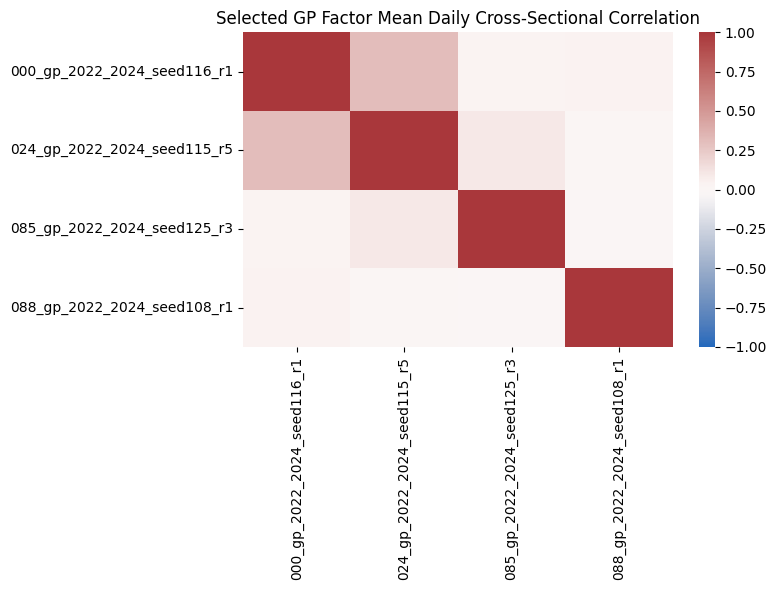

In [20]:
# Optional: inspect the strongest style dependency for each selected factor.
style_cols = [c for c in barra_summary.columns if c.startswith("mean_abs_beta_")]
if style_cols:
    top_style = barra_summary[["label"] + style_cols].set_index("label")
    top_style = top_style.apply(lambda s: s.sort_values(ascending=False).head(3).to_dict(), axis=1)
    display(top_style.to_frame("top_abs_style_betas"))

# Optional heatmap if seaborn is installed.
try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(max(8, len(selected_labels) * 0.35), max(6, len(selected_labels) * 0.35)))
    sns.heatmap(corr_matrix.loc[selected_labels, selected_labels], cmap="vlag", center=0, vmin=-1, vmax=1)
    plt.title("Selected GP Factor Mean Daily Cross-Sectional Correlation")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("heatmap skipped:", repr(exc))
